In [5]:

from utils.connector import postgres

def query(sql, params=None):
    with postgres() as pg:
        return pg.query(sql, params)

# Analiza jednostek

In [6]:
sql_chembl_ic50_units_human = """select * from chembl_ic50_units_human"""

data_units = query(sql_chembl_ic50_units_human)

/home/pkuszn/repos/WSzI/src/notebooks/utils/connector.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, self.conn, params=params)


Dane jednostek IC50 (ludzki, exact):
  standard_units  n_records     min_value     max_value    mean_value  \
0             nM    1584674  1.427000e-13  7.943282e+22  5.012567e+16   
1        ug.mL-1      22305  1.000000e-08  2.850000e+08  4.357987e+04   
2           None        159  2.000000e-03  2.020000e+03  2.987534e+01   
3             ug        136  5.000000e-03  3.000000e+02  4.029931e+01   
4        10^2 uM        114  7.000000e-02  1.320000e+01  2.033596e+00   

   median_value  
0        600.00  
1          5.81  
2          1.60  
3          1.95  
4          1.00  


/tmp/ipykernel_2030/1859414622.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='standard_units', y='n_records', data=data_units_sorted, palette='viridis')


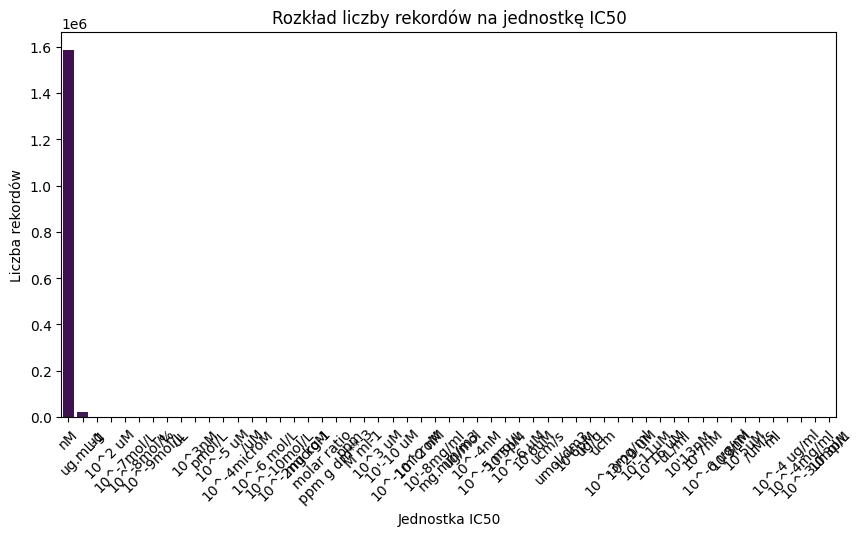

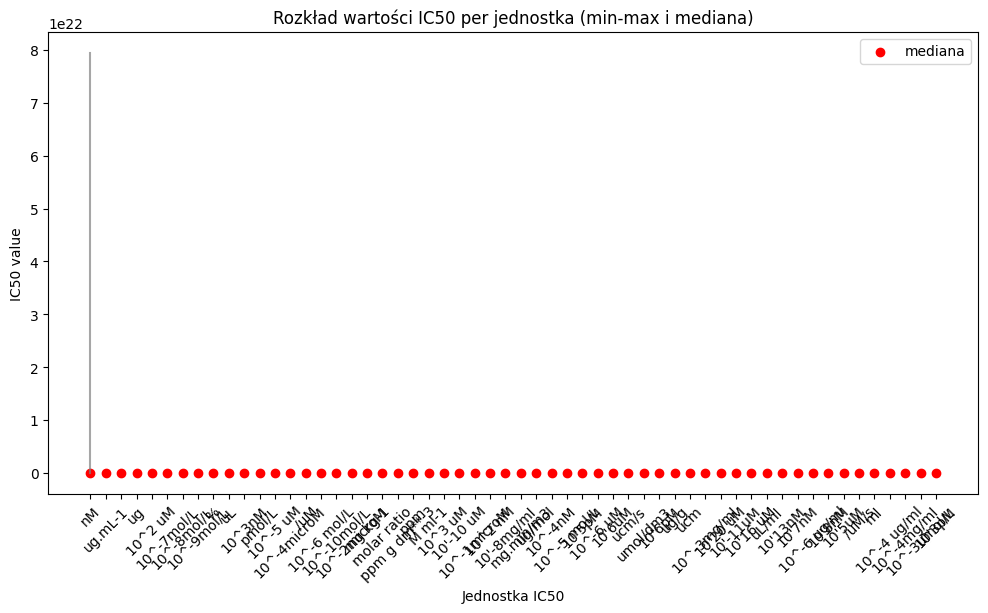

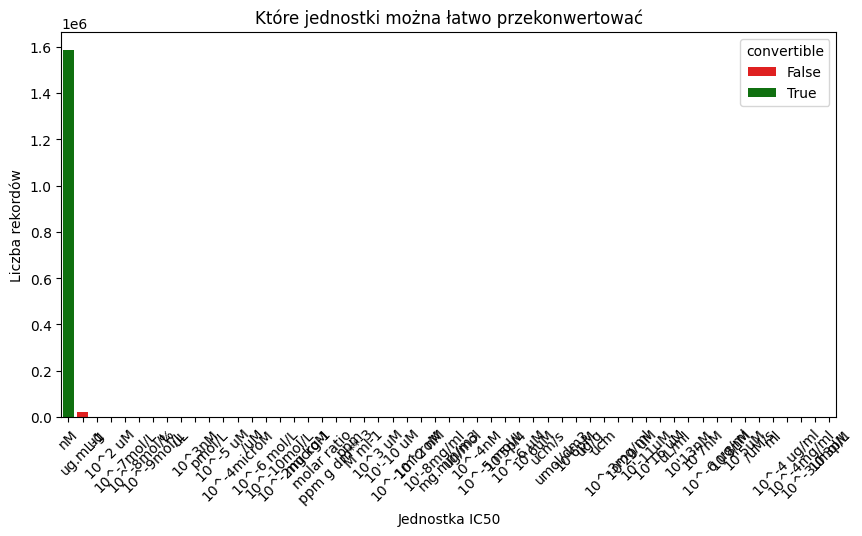

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Dane jednostek IC50 (ludzki, exact):")
print(data_units.head())

data_units_sorted = data_units.sort_values('n_records', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x='standard_units', y='n_records', data=data_units_sorted, palette='viridis')
plt.xticks(rotation=45)
plt.ylabel("Liczba rekordów")
plt.xlabel("Jednostka IC50")
plt.title("Rozkład liczby rekordów na jednostkę IC50")
plt.show()

plt.figure(figsize=(12,6))
for idx, row in data_units_sorted.iterrows():
    plt.plot([idx, idx], [row['min_value'], row['max_value']], color='gray', alpha=0.7)  # type: ignore # linia min-max
    plt.scatter(idx, row['median_value'], color='red', label='mediana' if idx==0 else "")  # type: ignore # mediana
plt.xticks(range(len(data_units_sorted)), data_units_sorted['standard_units'], rotation=45) # type: ignore
plt.ylabel("IC50 value")
plt.xlabel("Jednostka IC50")
plt.title("Rozkład wartości IC50 per jednostka (min-max i mediana)")
plt.legend()
plt.show()

data_units_sorted['convertible'] = data_units_sorted['standard_units'].isin(['pM','nM','uM','mM'])

plt.figure(figsize=(10,5))
sns.barplot(x='standard_units', y='n_records', hue='convertible', data=data_units_sorted, palette=['red','green'])
plt.xticks(rotation=45)
plt.ylabel("Liczba rekordów")
plt.xlabel("Jednostka IC50")
plt.title("Które jednostki można łatwo przekonwertować")
plt.show()


In [8]:
sql = """select * from chembl_pic50_compounds;"""

data = query(sql)

print(f"Compounds: {len(data)}")
print(f"Median assays / compound: {data['n_assays'].median():.1f}")
print(f"pIC50 range: {data['pIC50_median'].min():.2f} – {data['pIC50_median'].max():.2f}")
print(data.columns)

/home/pkuszn/repos/WSzI/src/notebooks/utils/connector.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, self.conn, params=params)


Compounds: 663139
Median assays / compound: 1.0
pIC50 range: 2.16 – 11.00
Index(['canonical_smiles', 'n_assays', 'pIC50_mean', 'pIC50_median',
       'pIC50_min', 'pIC50_max'],
      dtype='object')


# Histogram median pIC50

Im wyższa wartość pIC50, tym bardziej aktywny związek.

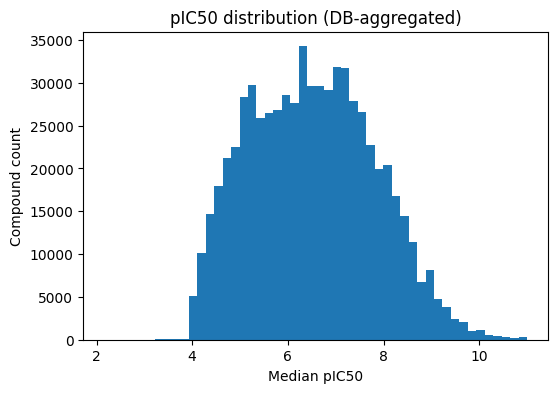

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(data['pIC50_median'], bins=50)
plt.xlabel("Median pIC50")
plt.ylabel("Compound count")
plt.title("pIC50 distribution (DB-aggregated)")
plt.show()

# Zmienność aktywności w obrębie każdego związku

- pIC50_range - rorzut aktywności danego związku
- Mały zakres - wszystkie assay są zbliżone, związek wydaje się stabilny
- Duży zakres - możliwe błędy pomiarowe, różne warunki eksperymentalne lub związek zachowuje się niestabilnie.

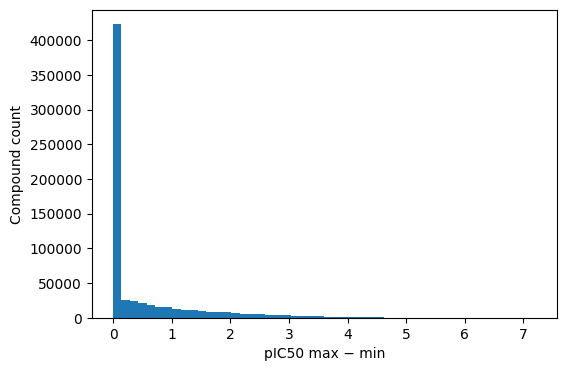

In [10]:
data['pIC50_range'] = data['pIC50_max'] - data['pIC50_min']

plt.figure(figsize=(6,4))
plt.hist(data['pIC50_range'], bins=50)
plt.xlabel("pIC50 max − min")
plt.ylabel("Compound count")
plt.show()

# Ile procent zwiążków ma niepewne (rozbieżne) wartości pIC50 ?

In [11]:
data['noisy'] = data['pIC50_range'] > 1.0
print(f"Noisy compounds: {data['noisy'].mean()*100:.1f}%")

Noisy compounds: 18.0%


# Liczba assayów na związek


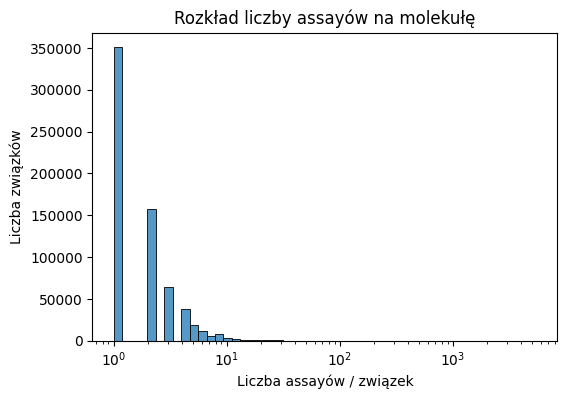

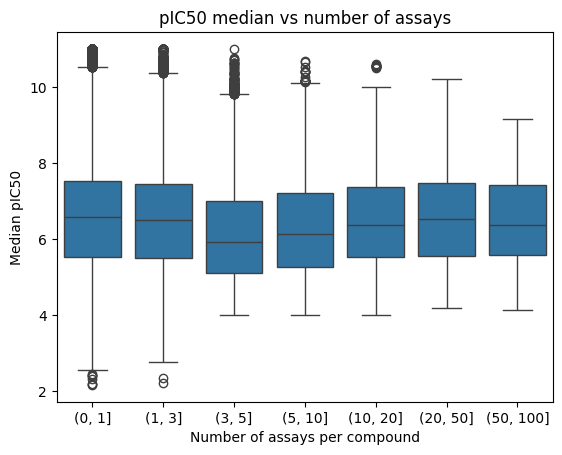

In [12]:
import seaborn as sns
import pandas as pd

plt.figure(figsize=(6,4))
sns.histplot(data['n_assays'], bins=50, log_scale=(True, False)) # type: ignore
plt.xlabel("Liczba assayów / związek")
plt.ylabel("Liczba związków")
plt.title("Rozkład liczby assayów na molekułę")
plt.show()

sns.boxplot(x=pd.cut(data['n_assays'], bins=[0,1,3,5,10,20,50,100]), y=data['pIC50_median'])
plt.xlabel("Number of assays per compound")
plt.ylabel("Median pIC50")
plt.title("pIC50 median vs number of assays")
plt.show()

# Korelacje między statystykami


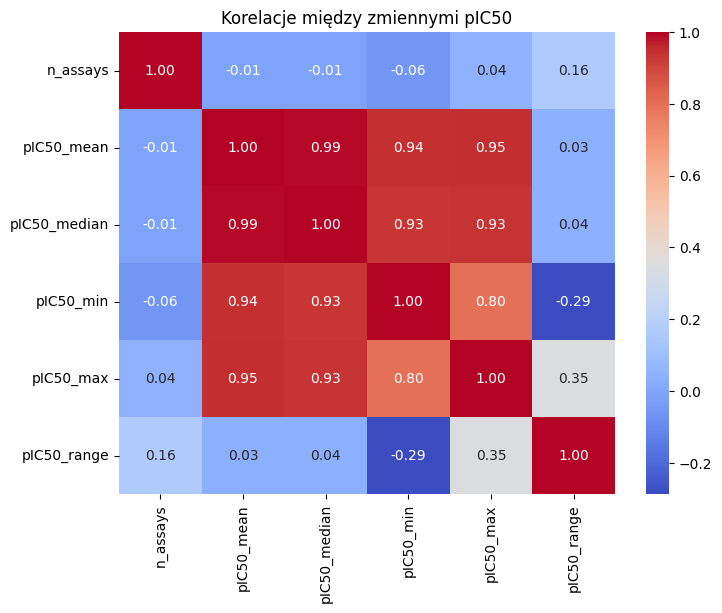

In [13]:
corr = data[['n_assays', 'pIC50_mean', 'pIC50_median', 'pIC50_min', 'pIC50_max', 'pIC50_range']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Korelacje między zmiennymi pIC50")
plt.show()

# Analiza noisy compounds

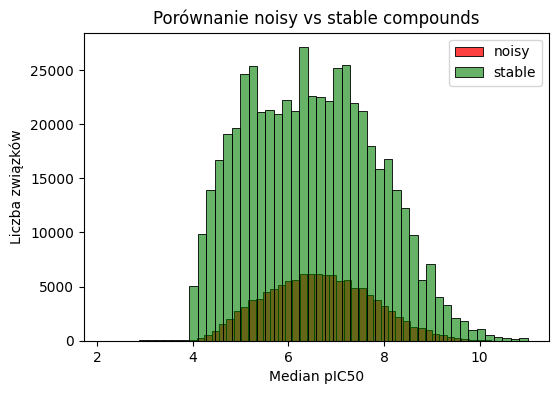

In [14]:
plt.figure(figsize=(6,4))
sns.histplot(data[data['noisy']==True]['pIC50_median'], bins=50, color='red', label='noisy')
sns.histplot(data[data['noisy']==False]['pIC50_median'], bins=50, color='green', label='stable', alpha=0.6)
plt.xlabel("Median pIC50")
plt.ylabel("Liczba związków")
plt.title("Porównanie noisy vs stable compounds")
plt.legend()
plt.show()

# Analiza zależności między medianą a rozrzutem

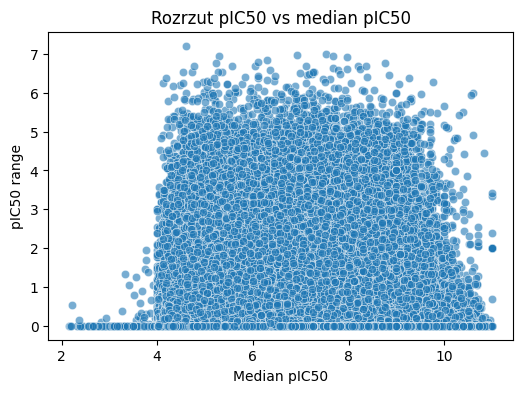

In [15]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='pIC50_median', y='pIC50_range', data=data, alpha=0.6)
plt.xlabel("Median pIC50")
plt.ylabel("pIC50 range")
plt.title("Rozrzut pIC50 vs median pIC50")
plt.show()

# Cechy molekularne a cechy atomowe / Test środowiska rdkit

cechy molekularne - opisują całą cząsteczke jako całość,
cechy atomowe - opisują pojedyncze atomowy lub ich lokalne środowisko w cząsteczce. 

## Deskryptory molekularne

In [16]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, QED

smiles = "CC(=O)Oc1ccccc1C(=O)O"  # Aspiryna
mol = Chem.MolFromSmiles(smiles)

# deskryptory molekularne
mol_weight = Descriptors.MolWt(mol)
logp = Descriptors.MolLogP(mol)
psa = rdMolDescriptors.CalcTPSA(mol)
hba = rdMolDescriptors.CalcNumHBA(mol)
hbd = rdMolDescriptors.CalcNumHBD(mol)
rot_bonds = Descriptors.NumRotatableBonds(mol)
qed_score = QED.qed(mol)

# ładne wyświetlenie
molecular_features = {
    "Molecular Weight": mol_weight,
    "LogP": logp,
    "TPSA": psa,
    "HBA (H-bond Acceptors)": hba,
    "HBD (H-bond Donors)": hbd,
    "Rotatable Bonds": rot_bonds,
    "QED (Drug-likeness)": qed_score
}

print("Molecular features for Aspirin:")
for feature, value in molecular_features.items():
    print(f"{feature:25}: {value:.3f}")

Molecular features for Aspirin:
Molecular Weight         : 180.159
LogP                     : 1.310
TPSA                     : 63.600
HBA (H-bond Acceptors)   : 3.000
HBD (H-bond Donors)      : 1.000
Rotatable Bonds          : 2.000
QED (Drug-likeness)      : 0.550


## Deskryptory atomowe

In [17]:
atom_features = []

for atom in mol.GetAtoms():
    atom_features.append({
        "atom_idx": atom.GetIdx(),
        "symbol": atom.GetSymbol(),
        "atomic_num": atom.GetAtomicNum(),
        "hybridization": str(atom.GetHybridization()),
        "formal_charge": atom.GetFormalCharge(),
        "aromatic": atom.GetIsAromatic(),
        "num_implicit_H": atom.GetNumImplicitHs(),
        "degree": atom.GetDegree(),
        "total_valence": atom.GetTotalValence()
    })

print("Atom features:")
for feat in atom_features:
    print(feat)

Atom features:
{'atom_idx': 0, 'symbol': 'C', 'atomic_num': 6, 'hybridization': 'SP3', 'formal_charge': 0, 'aromatic': False, 'num_implicit_H': 3, 'degree': 1, 'total_valence': 4}
{'atom_idx': 1, 'symbol': 'C', 'atomic_num': 6, 'hybridization': 'SP2', 'formal_charge': 0, 'aromatic': False, 'num_implicit_H': 0, 'degree': 3, 'total_valence': 4}
{'atom_idx': 2, 'symbol': 'O', 'atomic_num': 8, 'hybridization': 'SP2', 'formal_charge': 0, 'aromatic': False, 'num_implicit_H': 0, 'degree': 1, 'total_valence': 2}
{'atom_idx': 3, 'symbol': 'O', 'atomic_num': 8, 'hybridization': 'SP2', 'formal_charge': 0, 'aromatic': False, 'num_implicit_H': 0, 'degree': 2, 'total_valence': 2}
{'atom_idx': 4, 'symbol': 'C', 'atomic_num': 6, 'hybridization': 'SP2', 'formal_charge': 0, 'aromatic': True, 'num_implicit_H': 0, 'degree': 3, 'total_valence': 4}
{'atom_idx': 5, 'symbol': 'C', 'atomic_num': 6, 'hybridization': 'SP2', 'formal_charge': 0, 'aromatic': True, 'num_implicit_H': 1, 'degree': 2, 'total_valence': 

# pCI50 po konwersji

In [18]:
sql_chembl_ic50_all_units = """SELECT * FROM chembl_pic50_compounds_all_units"""

all_units = query(sql_chembl_ic50_all_units)
all_units.head()

/home/pkuszn/repos/WSzI/src/notebooks/utils/connector.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, self.conn, params=params)


,canonical_smiles,n_assays,pic50_mean,pic50_median,pic50_min,pic50_max,all_units
0,COc1cccc2c1C(=O)c1c(O)c3c(c(O)c1C2=O)C[C@@](O)...,5467,6.332208,6.301030,4.000000,10.327902,[nM]
1,O=C(CCCCCCC(=O)Nc1ccccc1)NO,3803,6.238839,6.079642,4.000000,9.677781,[nM]
2,CC(=O)O[C@H]1C(=O)[C@@]2(C)[C@H]([C@H](OC(=O)c...,2780,7.315124,7.675512,4.045757,11.000000,[nM]
3,O=c1[nH]cc(F)c(=O)[nH]1,2252,5.010481,4.946922,4.000000,8.397940,[nM]
4,COc1cc([C@@H]2c3cc4c(cc3[C@@H](O[C@@H]3O[C@@H]...,2071,5.551380,5.591760,4.000000,9.000000,[nM]


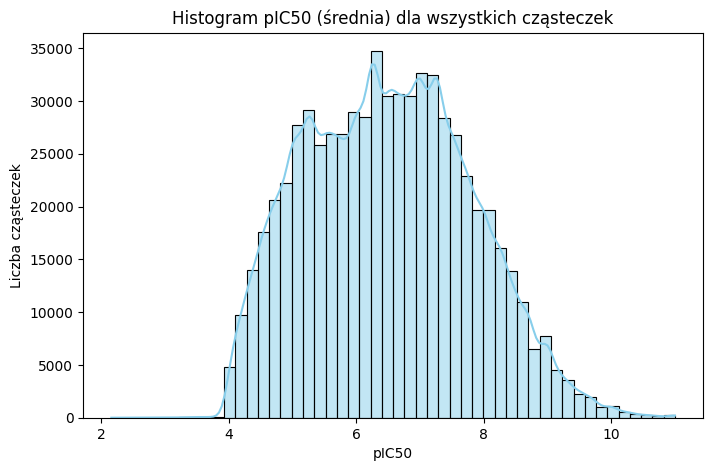

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(all_units['pic50_mean'], bins=50, kde=True, color='skyblue')
plt.title("Histogram pIC50 (średnia) dla wszystkich cząsteczek")
plt.xlabel("pIC50")
plt.ylabel("Liczba cząsteczek")
plt.show()

# Przekonwertowane IC50

In [21]:

sql_chembl_ic50_converted = """SELECT * FROM chembl_ic50_all_converted"""

all_units = query(sql_chembl_ic50_converted)
all_units.head()

/home/pkuszn/repos/WSzI/src/notebooks/utils/connector.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, self.conn, params=params)


,activity_id,assay_id,molregno,canonical_smiles,standard_value,standard_units,standard_type,relation,pchembl_value,data_validity_comment,activity_comment,src_id,ic50_molar,pic50
0,15633342,1502983,1950519,CCN1C(=S)N2CCCC2c2c1nc(C(C)N1CCOCC1)[nH]c2=O,2670.0,nM,IC50,=,5.57,None,None,1,2.670000e-06,5.573489
1,15612757,1499475,1947287,COc1cc(/C=C/C(=O)OC[C@H]2O[C@H](O[C@]3(CO)O[C@...,17200.0,nM,IC50,=,4.76,None,None,1,1.720000e-05,4.764472
2,15623119,1500328,1949708,Cc1ccc(-n2nc(-c3cccnc3)cc2NC(=O)c2cnn3cccnc23)cc1,99.0,nM,IC50,=,7.00,None,None,1,9.900000e-08,7.004365
3,15672061,1508738,1956159,CC1CC2=C(CO1)C(=O)c1ccccc1C2=O,25300.0,nM,IC50,=,4.60,None,None,1,2.530000e-05,4.596879
4,15672092,1508741,1956159,CC1CC2=C(CO1)C(=O)c1ccccc1C2=O,23200.0,nM,IC50,=,4.63,None,None,1,2.320000e-05,4.634512


## Ile jednostek zostało po konwersji, które dało się łatwo przekonwertować?

In [ ]:
total = len(all_units)

not_converted = all_units['ic50_molar'].isna().sum()
not_converted_pIC50 = all_units['pic50'].isna().sum()

print(f"Liczba wszystkich rekordów IC50: {total}")
print(f"Liczba rekordów bez ic50_molar (nieprzekonwertowane): {not_converted}")
print(f"Liczba rekordów bez pIC50 (nieprzekonwertowane): {not_converted_pIC50}")
print(f"Procent nieprzekonwertowanych (ic50_molar): {100*not_converted/total:.2f}%")
print(f"Procent nieprzekonwertowanych (pIC50): {100*not_converted_pIC50/total:.2f}%")

Liczba wszystkich rekordów IC50: 1545824
Liczba rekordów bez ic50_molar (nieprzekonwertowane): 20301
Liczba rekordów bez pIC50 (nieprzekonwertowane): 20301
Procent nieprzekonwertowanych (ic50_molar): 1.31%
Procent nieprzekonwertowanych (pIC50): 1.31%


## Statystyki na przekonwertowanym zbiorze

In [25]:
print(all_units.info())
print(all_units.describe())

print("Liczba unikalnych cząsteczek:", all_units['canonical_smiles'].nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1545824 entries, 0 to 1545823
Data columns (total 14 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   activity_id            1545824 non-null  int64  
 1   assay_id               1545824 non-null  int64  
 2   molregno               1545824 non-null  int64  
 3   canonical_smiles       1545824 non-null  object 
 4   standard_value         1545824 non-null  float64
 5   standard_units         1545665 non-null  object 
 6   standard_type          1545824 non-null  object 
 7   relation               1545824 non-null  object 
 8   pchembl_value          1525523 non-null  float64
 9   data_validity_comment  0 non-null        object 
 10  activity_comment       380347 non-null   object 
 11  src_id                 1545824 non-null  int64  
 12  ic50_molar             1525523 non-null  float64
 13  pic50                  1525523 non-null  float64
dtypes: float64(4), int

### Rozkład

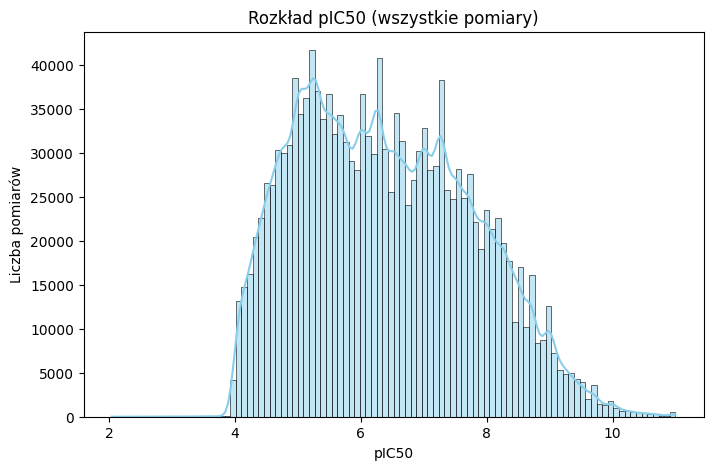

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(all_units['pic50'], bins=100, kde=True, color='skyblue')
plt.title("Rozkład pIC50 (wszystkie pomiary)")
plt.xlabel("pIC50")
plt.ylabel("Liczba pomiarów")
plt.show()

### Połączenie zbioru z deskryptorami molekularnymi


In [ ]:
sql_desc = "SELECT * FROM chembl_molecular_descriptors"
molecules = query(sql_desc)

# Połączenie po canonical_smiles
df = all_units.merge(molecules, on='canonical_smiles', how='left')

/home/pkuszn/repos/WSzI/src/notebooks/utils/connector.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, self.conn, params=params)


DatabaseError: Execution failed on sql 'SELECT * FROM chembl_molecular_descriptors': relation "chembl_molecular_descriptors" does not exist
LINE 1: SELECT * FROM chembl_molecular_descriptors
                      ^
